In [ ]:
# first introduction commit

In [1]:
import tensorflow as tf

train_dir = r"C:\Users\DELL\OneDrive\Desktop\fruit-vege\fruit-vegitable-image-classification\data\train"
val_dir = r"C:\Users\DELL\OneDrive\Desktop\fruit-vege\fruit-vegitable-image-classification\data\validation"
test_dir = r"C:\Users\DELL\OneDrive\Desktop\fruit-vege\fruit-vegitable-image-classification\data\test"

# Load training data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False
)

# Load validation data
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False
)





Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
## Model Building

In [3]:
cnn = tf.keras.models.Sequential()

In [4]:
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu', input_shape=(64, 64, 3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [5]:
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [6]:
cnn.add(tf.keras.layers.Dropout(0.5))

In [7]:
cnn.add(tf.keras.layers.Flatten())

In [8]:
cnn.add(tf.keras.layers.Dense(units=120, activation='relu'))

In [9]:
cnn.add(tf.keras.layers.Dense(units=36, activation='softmax'))

In [10]:
cnn.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
training_history = cnn.fit(x=train_ds, validation_data=val_ds, epochs=30)

Epoch 1/30


98/98 [==============================] - 58s 553ms/step - loss: 12.0201 - accuracy: 0.0337 - val_loss: 3.5161 - val_accuracy: 0.0684
Epoch 2/30
98/98 [==============================] - 45s 439ms/step - loss: 4.0130 - accuracy: 0.0549 - val_loss: 3.3160 - val_accuracy: 0.1396
Epoch 3/30
98/98 [==============================] - 53s 520ms/step - loss: 3.8237 - accuracy: 0.0841 - val_loss: 3.3004 - val_accuracy: 0.1937
Epoch 4/30
98/98 [==============================] - 69s 680ms/step - loss: 3.9840 - accuracy: 0.1226 - val_loss: 2.7222 - val_accuracy: 0.3504
Epoch 5/30
98/98 [==============================] - 61s 594ms/step - loss: 3.3315 - accuracy: 0.1859 - val_loss: 2.6855 - val_accuracy: 0.3105
Epoch 6/30
98/98 [==============================] - 68s 664ms/step - loss: 3.0859 - accuracy: 0.2427 - val_loss: 2.9862 - val_accuracy: 0.3419
Epoch 7/30
98/98 [==============================] - 76s 730ms/step - loss: 2.7742 - accuracy: 0.3175 - val_loss: 2.0764 - val_accuracy: 0.5

In [14]:
cnn.save('trained-model.keras')


In [15]:
training_history.history
import json
with open('training_hist.json','w') as f:
    json.dump(training_history.history,f)

In [16]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [17]:
training_history.history['val_accuracy'][-1]

0.94017094373703

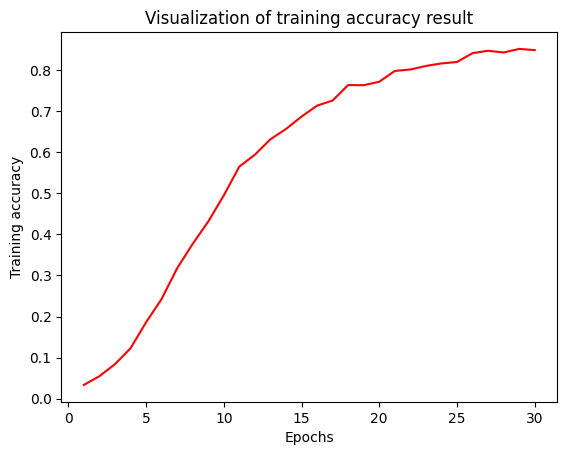

In [19]:
epochs = [i for i in range(1,31)]
plt.plot(epochs, training_history.history['accuracy'],color='red')
plt.xlabel('Epochs')
plt.ylabel('Training accuracy')
plt.title('Visualization of training accuracy result')
plt.show()

In [ ]:
plt.plot(epochs, training_history.history['accuracy'],color='red')
plt.xlabel('Epochs')
plt.ylabel('Training accuracy')
plt.title('Visualization of training accuracy result')
plt.show()